In [1]:
from agnpy.emission_regions import Cone
import astropy.units as u
from agnpy.spectra import ParticleDistribution
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import *
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
from agnpy.synchrotron.base_synchrotron import Synchrotron
import numpy as np
from astropy.constants import c, sigma_T, m_e, e, mu0
#e = e.gauss
mec2 = mec2.to('eV')
import matplotlib.pyplot as plt
h = h.cgs

In [2]:
h.cgs

<Quantity 6.62607015e-27 erg s>

In [3]:
(0.000000001*u.pc).to('cm')

<Quantity 3.08567758e+09 cm>

*Parameters used in Potter and Cotter to fit the BL Lac (Table 1)*

In [4]:
# Parameters used in Table 1 of Potter and Cotter; Fitting BL Lac (abdo et al. 2011)
z=0.0686
B_o =  (3.63 * 1e-5 * u.T).to(u.G)
u_B = ((B_to_cgs(B_o)**2)/(8*np.pi)).to('erg cm-3')
R_o = 7.32 * 1e15 * u.cm
W_j = 7.63 * 1e36* u.W
L = (330 * u.pc)
theta_open = 9.7 * u.deg
Gamma = 12
theta_s = 2 * u.deg
A_equi = 1.0
# Electron Distribution imposed by Potter and Cotter
p = 2
gamma_minimum = 1*(5.11 * 1e6 * u.eV / mec2.to("eV")).value
gamma_c = (5.6 * 1e9 * u.eV / mec2.to("eV")).value
n_e = ExpCutoffPowerLaw(k = 1 , mass=m_e, p=p, gamma_min = gamma_minimum, gamma_max= 100*gamma_c, gamma_c= gamma_c )


In [5]:
jet = Cone.from_jet_power(W_j = W_j , B_o = B_o, L = L, n_e = n_e, theta = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,delta_D=20.39,electron_escape = True, escape_coefficient =3)

In [6]:
jet_two = Cone.from_jet_power(W_j = W_j , B_o = B_o, L = L, n_e = n_e, theta = theta_open, Gamma=Gamma,x_size=100,gamma_e_size=1000, z =z,delta_D=20.39,electron_escape = False)

# Plots 

In [7]:
#Electron distribution
coordinates = [
    (585945.3915069195, 6.65905647933771e+45),
    (1180320.6356517298, 3.6753441641809446e+45),
    (2421029.04673618, 1.8950291465743076e+45),
    (5861381.645140285, 8.435148160601475e+44),
    (14454397.70745931, 3.481142923888426e+44),
    (23768402.866248783, 2.075324880373661e+44),
    (46989410.860521704, 1.1534180805525196e+44),
    (147231250.24327165, 3.8169973137017866e+43),
    (325087297.38543606, 1.693846972334023e+43),
    (831763771.1026742, 6.485157528062233e+42),
    (1614358556.8264935, 2.865619626947542e+42),
    (3076096814.7407174, 1.1725707943387419e+42),
    (5445026528.424242, 4.4349366153056454e+41),
    (10964781961.43192, 7.858944800779638e+40),
    (18030177408.59577, 1.2817831835790027e+40),
    (28575905433.749672, 1.2244668158998756e+39),
    (39084089579.24041, 1.164019524379192e+38),
    (59703528658.38415, 2.0753248803736612e+36),
    (89536476554.96011, 4.373153302721358e+33),
    (109647819614.31963, 7.740013565615246e+31),
    (129419584144.9997, 1.4766294411828247e+30)
]
x_data, y_data = zip(*coordinates)

# Data for the SED model of Synchrotron no-losses in Potter and Cotter in Figure 3 
x = [
    0.0003131660307862803, 0.0008840541623107365, 0.0029160081428143986, 0.001735547961136756,
    0.0014102489162420165, 0.0010879770097760172, 0.00781551761898938, 0.019888020057617743,
    0.048049640295616425, 0.1758208691205636, 0.6433550350871309, 1.7243273563482122,
    8.614126945081937, 16.05586850963554, 45.3250224803085, 109.50567327768607,
    238.4870429629985, 422.0385406871394, 639.1956383150009, 968.0894625777796,
    1392.0728770831072, 0.0000014950230456510178, 0.0000030912978018310354, 0.000007866375035417703,
    0.000027328746886507512, 0.00005093804274539881, 0.0001168437895408067
]

# Power / Flux data
y = [
    2.040490199884694e-12, 5.3169639633078265e-12, 1.503111337089843e-11, 1.08492128602697e-11,
    8.495785518249259e-12, 6.6528671251731555e-12, 2.1691180377984993e-11, 2.8852070927376698e-11,
    3.4659557108295606e-11, 4.249311650934016e-11, 4.705073061902792e-11, 4.6101686610606826e-11,
    3.396045117358661e-11, 2.7141154583473827e-11, 1.472792598364928e-11, 6.929596780336585e-12,
    2.169118037798499e-12, 6.652867125173156e-13, 1.842836161290166e-13, 4.163600255825478e-14,
    1.0000000000000041e-14, 1.0000000000000041e-14, 2.125365508342596e-14, 5.316963963307826e-14,
    1.769243507691091e-13, 3.327544666280575e-13, 7.672833112592147e-13
]
# Optional: sort the data by frequency for a smoother curve
sorted_data = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_data)

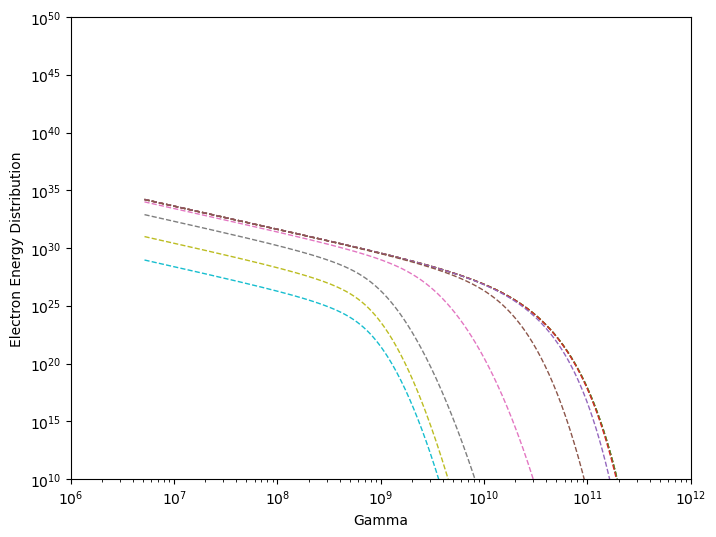

In [8]:
plt.figure(figsize=(8,6))
for i, _n_e_g in enumerate(jet.N_e_xg[::10]):
    plt.loglog(mec2.to('eV')*jet.gamma_e, _n_e_g, label=f"x={jet.x[10*i]}",linestyle='dashed',lw=1)
plt.xlabel('Gamma')
plt.ylabel('Electron Energy Distribution')
#plt.legend(fontsize=7)
plt.ylim(1e10,1e50)
plt.xlim(1e6,1e12)
plt.show()

In [9]:
for i, N_e_x in enumerate(jet.N_e_xg[::5]):
    print(np.trapz(N_e_x,jet.gamma_e))

1.6501377973000958e+35 1 / cm
1.6501375124818397e+35 1 / cm
1.6501364252788249e+35 1 / cm
1.6501322752356057e+35 1 / cm
1.650116433916847e+35 1 / cm
1.6500559670300193e+35 1 / cm
1.6498251879597787e+35 1 / cm
1.6489447593256845e+35 1 / cm
1.6455912279352174e+35 1 / cm
1.6328942396932708e+35 1 / cm
1.5858839518700797e+35 1 / cm
1.4251571356401938e+35 1 / cm
9.993674016705863e+34 1 / cm
3.960702127901996e+34 1 / cm
7.618900921830397e+33 1 / cm
9.277174605467296e+32 1 / cm
9.508803109829815e+31 1 / cm
9.264686428130459e+30 1 / cm
8.903921322135824e+29 1 / cm
8.526259095980168e+28 1 / cm


In [10]:
nu_obs = np.logspace(5, 25, 1000) * u.Hz
syn= Synchrotron(jet)
flux = syn.flux_obs(nu_obs)

In [11]:
syn_two = Synchrotron(jet_two)
flux_two = syn_two.flux_obs(nu_obs)

In [12]:
syn.evaluate_attenuation()

/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [2.91089606e-13, 3.14345108e-13, 3.39458854e-13, 3.66579366e-13,
           3.95867040e-13, 4.27495100e-13, 4.61650619e-13, 4.98535630e-13,
           5.38368324e-13, 5.81384338e-13, 6.27838157e-13, 6.78004618e-13,
           7.32180543e-13, 7.90686494e-13, 8.53868676e-13, 9.22100989e-13,
           9.95787246e-13, 1.07536357e-12, 1.16130097e-12, 1.25410815e-12,
           1.35433452e-12, 1.46257346e-12, 1.57946583e-12, 1.70570378e-12,
           1.84203489e-12, 1.98926655e-12, 2.14827079e-12, 2.31998948e-12,
           2.50543988e-12, 2.70572070e-12, 2.92201867e-12, 3.15561553e-12,
           3.40789571e-12, 3.68035452e-12, 3.97460706e-12, 4.29239786e-12,
           4.63561120e-12, 5.00628240e-12, 5.40660987e-12, 5.83896827e-12,
           6.30592260e-12, 6.81024354e-12, 7.35492390e-12, 7.94319656e-12,
           8.57855366e-12, 9.26476751e-12, 1.00059130e-11, 1.08063922e-11,
           1.16709603e-11, 1.26047542e-11, 1.36133232e-11, 1.47026623e-11,
           1.58792480e-11

In [13]:
syn_two.evaluate_attenuation()

<Quantity [1.36582604e-13, 1.47496013e-13, 1.59281654e-13, 1.72009265e-13,
           1.85754158e-13, 2.00597673e-13, 2.16627657e-13, 2.33938983e-13,
           2.52634119e-13, 2.72823728e-13, 2.94627330e-13, 3.18174008e-13,
           3.43603179e-13, 3.71065415e-13, 4.00723341e-13, 4.32752602e-13,
           4.67342900e-13, 5.04699129e-13, 5.45042586e-13, 5.88612288e-13,
           6.35666392e-13, 6.86483733e-13, 7.41365477e-13, 8.00636916e-13,
           8.64649401e-13, 9.33782431e-13, 1.00844592e-12, 1.08908262e-12,
           1.17617078e-12, 1.27022697e-12, 1.37180919e-12, 1.48152015e-12,
           1.60001092e-12, 1.72798476e-12, 1.86620134e-12, 2.01548128e-12,
           2.17671103e-12, 2.35084817e-12, 2.53892712e-12, 2.74206536e-12,
           2.96147005e-12, 3.19844529e-12, 3.45439991e-12, 3.73085592e-12,
           4.02945757e-12, 4.35198126e-12, 4.70034614e-12, 5.07662565e-12,
           5.48305993e-12, 5.92206928e-12, 6.39626869e-12, 6.90848355e-12,
           7.46176662e-12

In [14]:
sed_nossa_two= syn_two.sed_flux(nu_obs, ssa=False)
sed_ssa_two= syn_two.sed_flux(nu_obs, ssa=True)

In [15]:
sed_nossa= syn.sed_flux(nu_obs, ssa=False)
sed_ssa= syn.sed_flux(nu_obs, ssa=True)

In [16]:
sed_x_nossa = syn.sed_spatial(nu_obs) 
sed_x_ssa = syn.sed_spatial(nu_obs,ssa=True)

/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: divide by zero encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: overflow encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:36: RuntimeWarning: invalid value encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_cone.py:37: RuntimeWarning: overflow encountered in divide
  return np.where(tau < 1e-3, 1, 3 * u / tau)


# SED

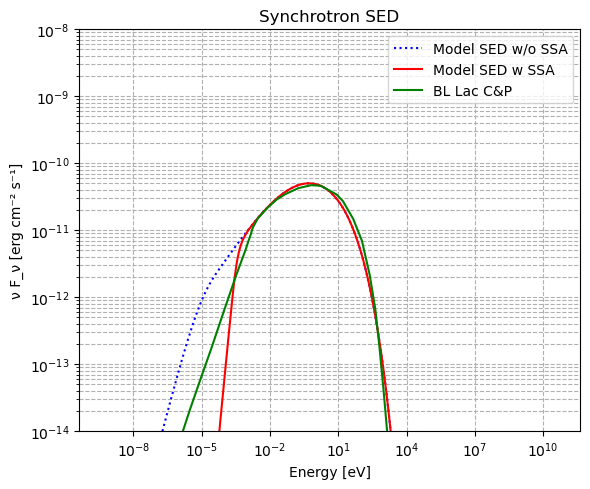

In [17]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', linestyle='solid', label='Model SED w SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_blob, color='black', linestyle='dotted', label='Model SED w Blob')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-8)
#plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()

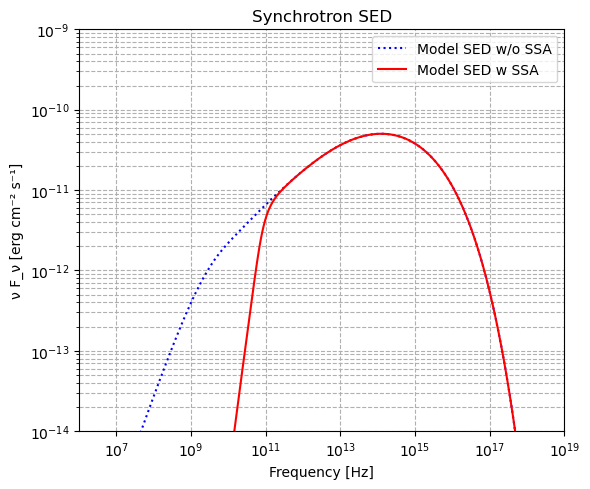

In [18]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs), sed_nossa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
plt.loglog((nu_obs), sed_ssa, color='red', linestyle='solid', label='Model SED w SSA')
plt.xlabel("Frequency [Hz]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-9)
plt.xlim(1e6,1e19)
plt.legend()
plt.tight_layout()
plt.show()

'\nfor i, sed in enumerate(sed_x_ssa[::50]):\n    axes[1].loglog(nu_obs, sed, linestyle=\'dashed\', lw=0.5,label = jet.x[50*i])\n#axes[1].loglog((nu_obs), np.trapz(sed_x_ssa,jet.x,axis = 0), linestyle=\'solid\', color=\'red\',label=\'Model SED w SSA\')\naxes[1].set_title("Synchrotron SED (With SSA)")\naxes[1].loglog(nu_obs, np.trapz(sed_x_ssa,jet.x,axis=0),color=\'blue\')\naxes[1].set_xlabel("Frequency (Hz)")\naxes[1].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")\naxes[1].grid(True, which=\'both\', ls=\'--\')\naxes[1].set_ylim(1e-14, 1e-9)\naxes[1].set_xlim(1e2,1e22)\naxes[1].legend(fontsize=5)\nplt.tight_layout()\nplt.show()\n'

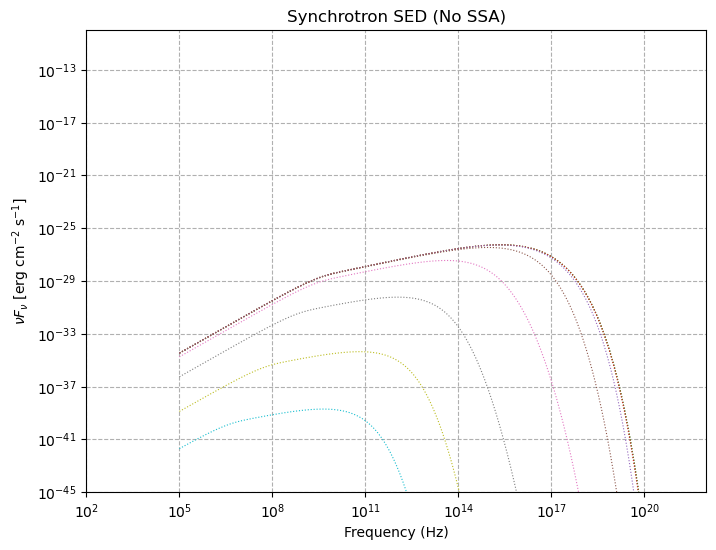

In [19]:
#SED @ x
fig, axes = plt.subplots(1,1, figsize=(8, 6), sharex=True)

# -------------------------
# Top: without SSA
# -------------------------
for i, sed in enumerate(sed_x_nossa[::10]):
    axes.loglog(nu_obs, sed, linestyle='dotted',lw=0.8,label = jet.x[10*i])
#axes.loglog(nu_obs, np.trapz(sed_x_nossa,jet.x,axis = 0), linestyle='solid', color='red',label='Model SED w/o SSA')
#axes.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
axes.set_title("Synchrotron SED (No SSA)")
axes.set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes.set_xlabel("Frequency (Hz)")
axes.grid(True, which='both', ls='--')
axes.set_ylim(1e-45, 1e-10)
axes.set_xlim(1e2,1e22)
#axes.legend(fontsize=7)
""""""
# -------------------------
# Bottom: with SSA
# -------------------------
"""
for i, sed in enumerate(sed_x_ssa[::50]):
    axes[1].loglog(nu_obs, sed, linestyle='dashed', lw=0.5,label = jet.x[50*i])
#axes[1].loglog((nu_obs), np.trapz(sed_x_ssa,jet.x,axis = 0), linestyle='solid', color='red',label='Model SED w SSA')
axes[1].set_title("Synchrotron SED (With SSA)")
axes[1].loglog(nu_obs, np.trapz(sed_x_ssa,jet.x,axis=0),color='blue')
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes[1].grid(True, which='both', ls='--')
axes[1].set_ylim(1e-14, 1e-9)
axes[1].set_xlim(1e2,1e22)
axes[1].legend(fontsize=5)
plt.tight_layout()
plt.show()
"""


(100000000000.0, 1e+22)

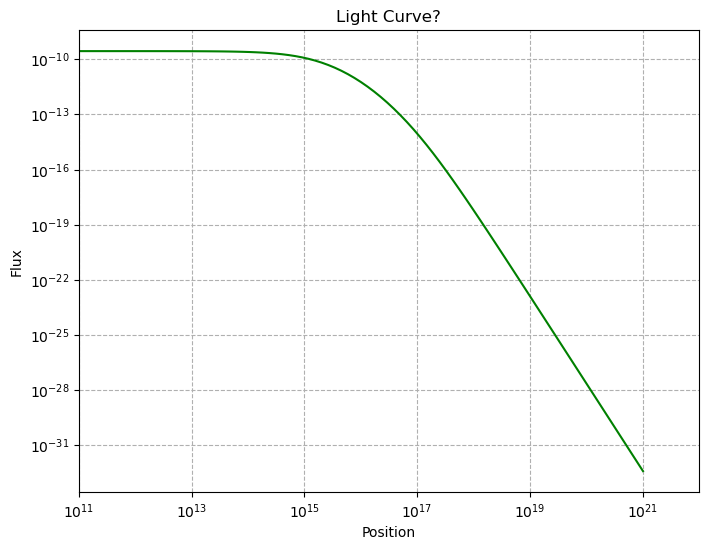

In [20]:
#Light Curve?
fig, axes = plt.subplots(1,1, figsize=(8, 6), sharex=True)
axes.loglog(jet.x, np.trapz(sed_x_nossa,nu_obs), linestyle='solid', color='green')
axes.set_title("Light Curve?")
axes.set_ylabel("Flux")
axes.set_xlabel("Position")
axes.grid(True, which='both', ls='--')
#axes.set_ylim(1e-45, 1e-10)
axes.set_xlim(1e11,1e22)

(1e-08, 1000000.0)

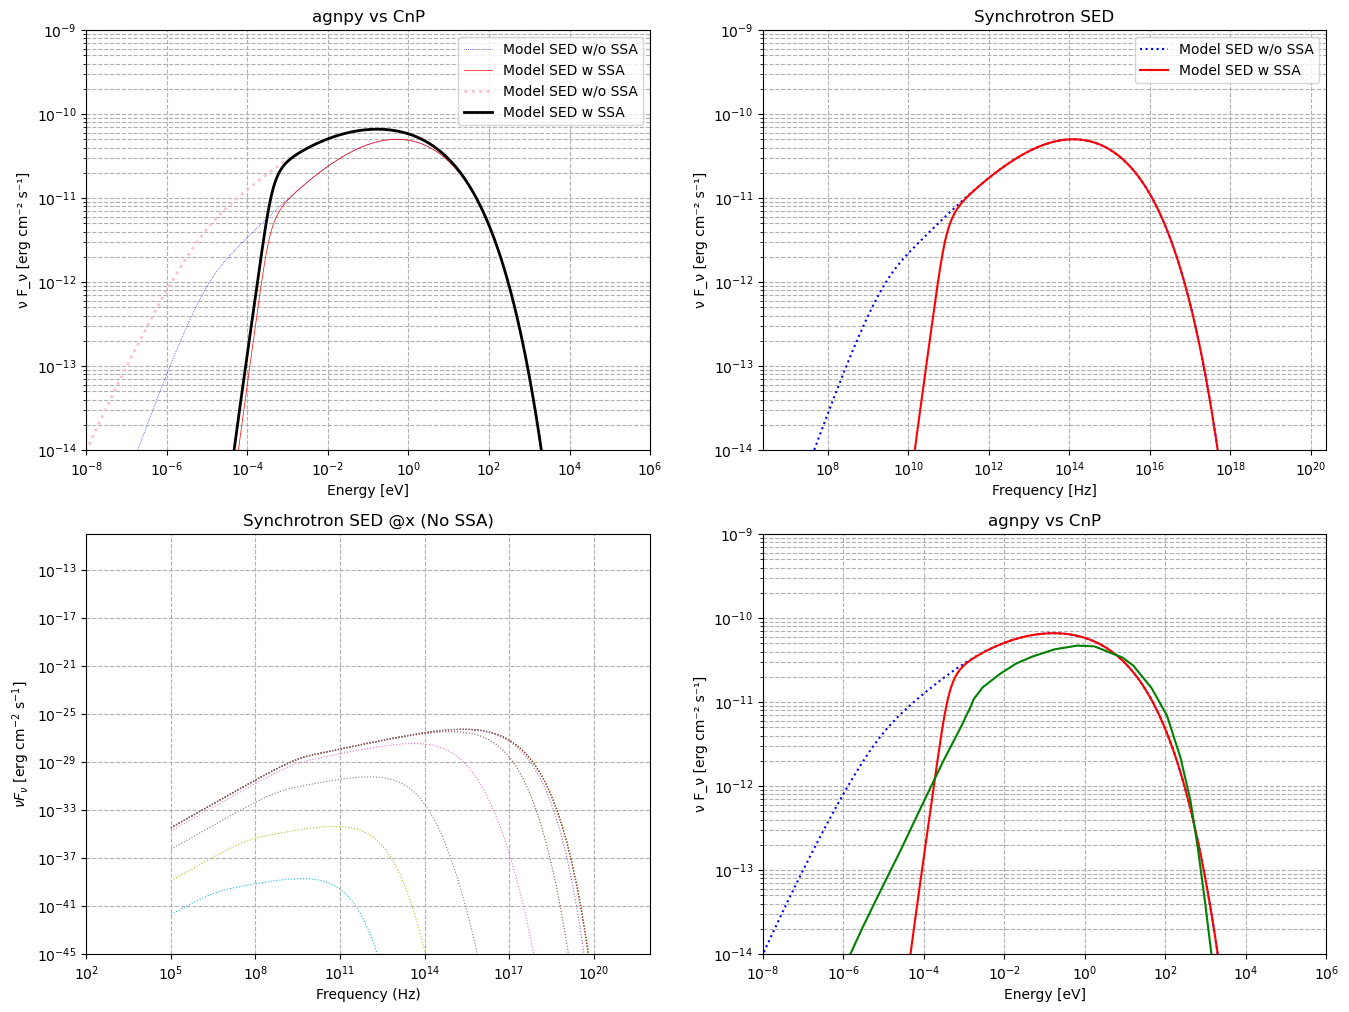

In [21]:
fig, axes = plt.subplots(2,2, figsize=(16, 12))

axes[0,0].loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa, color='blue', lw=0.5, linestyle='dotted', label='Model SED w/o SSA')
axes[0,0].loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red',lw=0.5, linestyle='solid', label='Model SED w SSA')
axes[0,0].loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa_two, color='pink',lw=2, linestyle='dotted', label='Model SED w/o SSA')
axes[0,0].loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa_two, color='black',lw=2, linestyle='solid', label='Model SED w SSA')
# Overlay updated data points
#axes[0,0].loglog(x_sorted, y_sorted, linestyle='solid', color='skyblue',label='BL Lac C&P')
axes[0,0].set_xlabel("Energy [eV]")
axes[0,0].set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes[0,0].set_title("agnpy vs CnP")
axes[0,0].grid(True, which='both', ls='--')
axes[0,0].set_ylim(1e-14, 1e-9)
axes[0,0].set_xlim(1e-8, 1e6)
axes[0,0].legend()

axes[0,1].loglog((nu_obs), sed_nossa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
axes[0,1].loglog((nu_obs), sed_ssa, color='red', linestyle='solid', label='Model SED w SSA')
axes[0,1].set_xlabel("Frequency [Hz]")
axes[0,1].set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes[0,1].set_title("Synchrotron SED")
axes[0,1].grid(True, which='both', ls='--')
axes[0,1].set_ylim(1e-14, 1e-9)
axes[0,1].set_xlim(((1e-8*u.eV).to('Hz',equivalencies=u.spectral()).value),((1e6*u.eV).to('Hz',equivalencies=u.spectral()).value))
axes[0,1].legend()


for i, sed in enumerate(sed_x_nossa[::10]):
    axes[1,0].loglog(nu_obs, sed, linestyle='dotted',lw=0.8,label = jet.x[10*i])
axes[1,0].set_title("Synchrotron SED @x (No SSA)")
axes[1,0].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes[1,0].set_xlabel("Frequency (Hz)")
axes[1,0].grid(True, which='both', ls='--')
axes[1,0].set_ylim(1e-45, 1e-10)
axes[1,0].set_xlim(1e2,1e22)

axes[1,1].loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa_two, color='blue', linestyle='dotted', label='Model SED w/o SSA')
axes[1,1].loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa_two, color='red', linestyle='solid', label='Model SED w SSA')
# Overlay updated data points
axes[1,1].loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
axes[1,1].set_xlabel("Energy [eV]")
axes[1,1].set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes[1,1].set_title("agnpy vs CnP")
axes[1,1].grid(True, which='both', ls='--')
axes[1,1].set_ylim(1e-14, 1e-9)
axes[1,1].set_xlim(1e-8, 1e6)

In [22]:
"""
fig, axes = plt.subplots(1,1, figsize=(6, 8))

axes.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa_two, color='blue', linestyle='dotted', label='Model SED w/o SSA')
axes.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa_two, color='red', linestyle='solid', label='Model SED w SSA')
# Overlay updated data points
axes.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
axes.set_xlabel("Energy [eV]")
axes.set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")
axes.set_title("agnpy vs CnP")
axes.grid(True, which='both', ls='--')
#axes.set_ylim(1e-14, 1e-9)
#axes.set_xlim(1e-8, 1e6)


for i, sed in enumerate(sed_x_nossa[::10]):
    axes[1,0].loglog(nu_obs, sed, linestyle='dotted',lw=0.8,label = jet.x[10*i])
axes[1,0].set_title("Synchrotron SED @x (No SSA)")
axes[1,0].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes[1,0].set_xlabel("Frequency (Hz)")
axes[1,0].grid(True, which='both', ls='--')
axes[1,0].set_ylim(1e-45, 1e-10)
axes[1,0].set_xlim(1e2,1e22)

axes[1,1].loglog(jet.x, np.trapz(sed_x_nossa,nu_obs), linestyle='solid', color='green')
axes[1,1].set_title("Light Curve?")
axes[1,1].set_ylabel("Flux")
axes[1,1].set_xlabel("Position")
axes[1,1].grid(True, which='both', ls='--')
#axes[1,1].set_ylim(1e-15, 1e-10)
axes[1,1].set_xlim(1e11,1e22)
"""

'\nfig, axes = plt.subplots(1,1, figsize=(6, 8))\n\naxes.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa_two, color=\'blue\', linestyle=\'dotted\', label=\'Model SED w/o SSA\')\naxes.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa_two, color=\'red\', linestyle=\'solid\', label=\'Model SED w SSA\')\n# Overlay updated data points\naxes.loglog(x_sorted, y_sorted, linestyle=\'solid\', color=\'green\',label=\'BL Lac C&P\')\naxes.set_xlabel("Energy [eV]")\naxes.set_ylabel("ν F_ν [erg cm⁻² s⁻¹]")\naxes.set_title("agnpy vs CnP")\naxes.grid(True, which=\'both\', ls=\'--\')\n#axes.set_ylim(1e-14, 1e-9)\n#axes.set_xlim(1e-8, 1e6)\n\n\nfor i, sed in enumerate(sed_x_nossa[::10]):\n    axes[1,0].loglog(nu_obs, sed, linestyle=\'dotted\',lw=0.8,label = jet.x[10*i])\naxes[1,0].set_title("Synchrotron SED @x (No SSA)")\naxes[1,0].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")\naxes[1,0].set_xlabel("Frequency (Hz)")\naxes[1,0].grid(True, which=\'both\', ls=\'--\')\naxes[

In [23]:
(x_sorted[-1]*u.eV).to(u.Hz, equivalencies=u.spectral())

<Quantity 3.36601724e+17 Hz>

In [24]:
"""
escape_terms = np.arange(0.25, 5, 0.25)

seds_nossa = {}
seds_ssa = {}

for escape in escape_terms:
    jet = Cone.from_jet_power(
        W_j=W_j,
        B_o=B_o,
        L=L,
        n_e=n_e,
        theta=theta_open,
        Gamma=Gamma,
        x_size=100,
        gamma_e_size=1000,
        z=z,
        delta_D=20.39,
        electron_escape=True,
        escape_coefficient=escape,
    )

    syn= Synchrotron(jet)
    flux = syn.flux_obs(nu_obs)
    syn.evaluate_attenuation()
    seds_nossa[escape]= syn.sed_flux(nu_obs, ssa=False)
    seds_ssa[escape]= syn.sed_flux(nu_obs, ssa=True)
    """

'\nescape_terms = np.arange(0.25, 5, 0.25)\n\nseds_nossa = {}\nseds_ssa = {}\n\nfor escape in escape_terms:\n    jet = Cone.from_jet_power(\n        W_j=W_j,\n        B_o=B_o,\n        L=L,\n        n_e=n_e,\n        theta=theta_open,\n        Gamma=Gamma,\n        x_size=100,\n        gamma_e_size=1000,\n        z=z,\n        delta_D=20.39,\n        electron_escape=True,\n        escape_coefficient=escape,\n    )\n\n    syn= Synchrotron(jet)\n    flux = syn.flux_obs(nu_obs)\n    syn.evaluate_attenuation()\n    seds_nossa[escape]= syn.sed_flux(nu_obs, ssa=False)\n    seds_ssa[escape]= syn.sed_flux(nu_obs, ssa=True)\n    '

In [25]:
"""
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for escape in escape_terms[::1]:
    axes[0].loglog(
        nu_obs.to(u.eV, equivalencies=u.spectral()),
        seds_nossa[escape],
        label=f"escape={escape}",
        lw=0.5
    )

for escape in escape_terms[::5]:
    axes[1].loglog(
        nu_obs.to(u.eV, equivalencies=u.spectral()),
        seds_nossa[escape],
        label=f"escape={escape}",
        lw=0.5
    )

axes[1].loglog(
    x_sorted,
    y_sorted,
    linestyle='solid',
    color='green',
    label='BL Lac C&P'
)

for escape in escape_terms[::5]:
    axes[2].loglog(
        nu_obs.to(u.eV, equivalencies=u.spectral()),
        seds_ssa[escape],
        label=f"escape={escape}",
        lw=0.5
    )
axes[2].loglog(
    x_sorted,
    y_sorted,
    linestyle='solid',
    color='green',
    label='BL Lac C&P'
)

axes[1].legend(fontsize=7)
axes[2].legend(fontsize=7)
axes[0].legend(fontsize=7)
axes[1].set_ylim(1e-14, 1e-9)
axes[2].set_ylim(1e-14, 1e-9)
axes[0].set_ylim(1e-14, 1e-9)
axes[1].set_xlim(1e-8, 1e6)
axes[2].set_xlim(1e-8, 1e6)
axes[0].set_xlim(1e-8, 1e6)

plt.tight_layout()
plt.show()
"""

'\nfig, axes = plt.subplots(3, 1, figsize=(10, 12))\n\nfor escape in escape_terms[::1]:\n    axes[0].loglog(\n        nu_obs.to(u.eV, equivalencies=u.spectral()),\n        seds_nossa[escape],\n        label=f"escape={escape}",\n        lw=0.5\n    )\n\nfor escape in escape_terms[::5]:\n    axes[1].loglog(\n        nu_obs.to(u.eV, equivalencies=u.spectral()),\n        seds_nossa[escape],\n        label=f"escape={escape}",\n        lw=0.5\n    )\n\naxes[1].loglog(\n    x_sorted,\n    y_sorted,\n    linestyle=\'solid\',\n    color=\'green\',\n    label=\'BL Lac C&P\'\n)\n\nfor escape in escape_terms[::5]:\n    axes[2].loglog(\n        nu_obs.to(u.eV, equivalencies=u.spectral()),\n        seds_ssa[escape],\n        label=f"escape={escape}",\n        lw=0.5\n    )\naxes[2].loglog(\n    x_sorted,\n    y_sorted,\n    linestyle=\'solid\',\n    color=\'green\',\n    label=\'BL Lac C&P\'\n)\n\naxes[1].legend(fontsize=7)\naxes[2].legend(fontsize=7)\naxes[0].legend(fontsize=7)\naxes[1].set_ylim(1e

# Comparing against Dermer's Synchrotron SED

In [26]:
from astropy.table import Table

In [27]:
dermer_synchrotron_1e5 = Table.read(
    "/Users/usharma/Documents/GitHub/agnpy/agnpy/data/reference_seds/dermer_menon_2009/figure_7_4/synchrotron_gamma_max_1e5.txt",
    format="ascii.csv",
    comment="#",
    names=["nu_Hz", "nuFnu"]
)

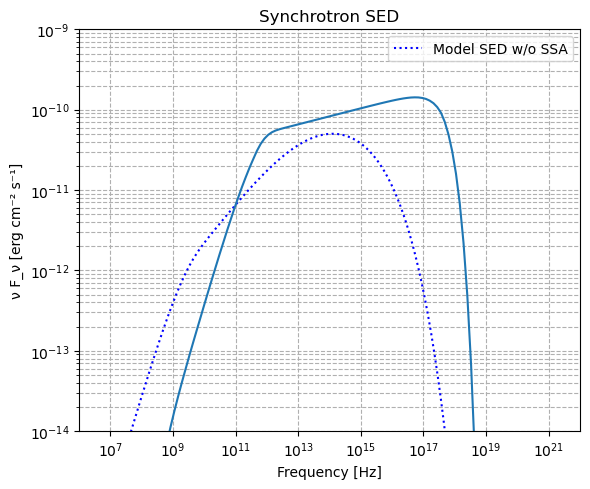

In [28]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs), sed_nossa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
#plt.loglog((nu_obs), sed_ssa, color='red', linestyle='solid', label='Model SED w SSA')
plt.loglog(dermer_synchrotron_1e5['nu_Hz'],dermer_synchrotron_1e5['nuFnu'])
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_blob, color='black', linestyle='dotted', label='Model SED w Blob')
# Overlay updated data points
#plt.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
plt.xlabel("Frequency [Hz]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-9)
plt.xlim(1e6,1e22)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
jet.R_o

<Quantity 2.31629592e+16 cm>

In [39]:
from agnpy.spectra import PowerLaw

from astropy.coordinates import Distance
# set the quantities defining the blob
R_b = 0.5 * 2.31 * 1e16 * u.cm
V_b = 4 / 3 * np.pi * R_b ** 3
z = 0.0686
delta_D = 20.39
Gamma = 12
B = 0.363 * u.G

# define the emission region and the radiative process
blob = Blob(R_b, z, delta_D, Gamma, B, n_e=n_e)
synch = Synchrotron(blob, ssa=True)

# compute the SED over an array of frequencies
nu = np.logspace(5, 23) * u.Hz
sed = synch.sed_flux(nu)

[[3.43840275e-05 8.01131271e-05 1.86659726e-04 ... 6.33377845e+12
  1.47573986e+13 3.43840275e+13]
 [3.05989004e-05 7.12939633e-05 1.66111499e-04 ... 5.63653155e+12
  1.31328469e+13 3.05989004e+13]
 [2.72304547e-05 6.34456473e-05 1.47825301e-04 ... 5.01604029e+12
  1.16871322e+13 2.72304547e+13]
 ...
 [3.61513353e-15 8.42308692e-15 1.96253866e-14 ... 6.65932892e+02
  1.55159155e+03 3.61513353e+03]
 [3.21716561e-15 7.49584084e-15 1.74649479e-14 ... 5.92624416e+02
  1.38078633e+03 3.21716561e+03]
 [2.86300754e-15 6.67066960e-15 1.55423387e-14 ... 5.27386021e+02
  1.22878401e+03 2.86300754e+03]]
[[3.43840275e-05 8.01131271e-05 1.86659726e-04 ... 6.33377845e+12
  1.47573986e+13 3.43840275e+13]
 [3.05989004e-05 7.12939633e-05 1.66111499e-04 ... 5.63653155e+12
  1.31328469e+13 3.05989004e+13]
 [2.72304547e-05 6.34456473e-05 1.47825301e-04 ... 5.01604029e+12
  1.16871322e+13 2.72304547e+13]
 ...
 [3.61513353e-15 8.42308692e-15 1.96253866e-14 ... 6.65932892e+02
  1.55159155e+03 3.61513353e+03]

/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_blob.py:70: RuntimeWarning: divide by zero encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/synchrotron_blob.py:70: RuntimeWarning: invalid value encountered in divide
  u = 1 / 2 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)


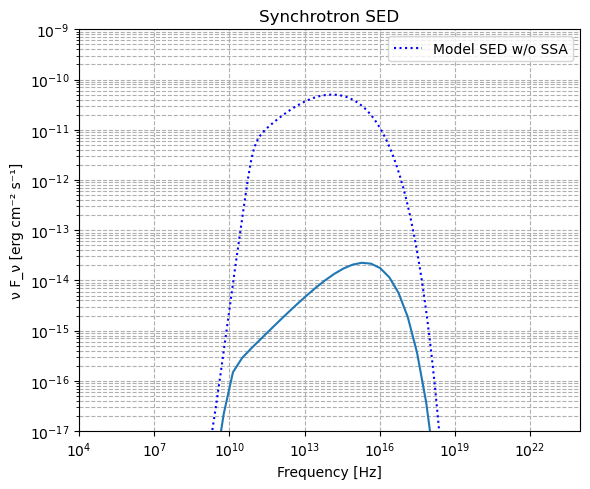

In [40]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs), sed_ssa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
plt.loglog(nu, sed)
plt.xlabel("Frequency [Hz]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-17, 1e-9)
plt.xlim(1e4,1e24)
plt.legend()
plt.tight_layout()
plt.show()